# PlantVillage Disease Dataset — KD + FP16 QAT Pipeline
## Same methodology as Potato dataset (ViT-B/16 Teacher → EfficientNet-B0 Student → FP16 QAT)
### No cross-validation — stratified 80/10/10 train/val/test split

In [ ]:
# ── CELL 1 ───────────────────────────────────────────────────────
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DATA_DIR = "/content/drive/MyDrive/Research/Plant_leave_diseases_dataset_without_augmentation"

OUTPUT_DIR = "/content/drive/MyDrive/Research/Model_save/PlantVillage"
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = sorted([
    d for d in os.listdir(DRIVE_DATA_DIR)
    if os.path.isdir(os.path.join(DRIVE_DATA_DIR, d))
])

print(f"Found {len(classes)} classes in Drive:")
for c in classes:
    n = len([
        f for f in os.listdir(os.path.join(DRIVE_DATA_DIR, c))
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    print(f"  {c}: {n} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 37 classes in Drive:
  Apple___Apple_scab: 630 images
  Apple___Black_rot: 621 images
  Apple___Cedar_apple_rust: 275 images
  Apple___healthy: 1645 images
  Cherry___Powdery_mildew: 1052 images
  Cherry___healthy: 854 images
  Corn___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn___Common_rust: 1192 images
  Corn___Northern_Leaf_Blight: 985 images
  Corn___healthy: 1162 images
  Grape___Black_rot: 1180 images
  Grape___Esca_(Black_Measles): 1383 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076 images
  Grape___healthy: 423 images
  Orange___Haunglongbing_(Citrus_greening): 5523 images
  Peach___Bacterial_spot: 2347 images
  Peach___healthy: 360 images
  Pepper,_bell___Bacterial_spot: 997 images
  Pepper,_bell___healthy: 1478 images
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images
 

In [ ]:
# ── CELL 2: Copy dataset to local SSD ───────────
import shutil, time

LOCAL_DATA = "/content/PlantVillage"

if not os.path.exists(LOCAL_DATA):
    print("Copying dataset from Drive to local SSD...")
    print("This takes ~5-8 minutes once. Every epoch will be fast after this.")
    t0 = time.time()
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA)
    print(f"Done in {(time.time()-t0)/60:.1f} min")
else:
    print("Local copy already exists — skipping copy.")

# Use local path from now on
DATA_DIR = LOCAL_DATA

classes = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"\nLocal dataset ready: {len(classes)} classes")

Copying dataset from Drive to local SSD...
This takes ~5-8 minutes once. Every epoch will be fast after this.
Done in 17.0 min

Local dataset ready: 37 classes


In [ ]:
# ── CELL 3: Imports ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets, models
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                              accuracy_score, classification_report)
from sklearn.model_selection import train_test_split
import numpy as np
import os, csv, copy, json, random, time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import timm
from pathlib import Path
from PIL import Image

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda


In [ ]:
# ── CELL 4: Hyperparameters & Config ─────────────────────────────────────────
CFG = {
    # Data
    "data_dir"   : DATA_DIR,
    "output_dir" : OUTPUT_DIR,
    "img_size"   : 224,
    "batch_size" : 64,
    "num_workers": 4,
    # Splits (stratified)
    "train_frac" : 0.80,
    "val_frac"   : 0.10,
    "test_frac"  : 0.10,
    "random_seed": 42,
    # Teacher training
    "teacher_epochs"  : 30,
    "teacher_base_lr" : 5e-5,
    "teacher_wd"      : 1e-4,
    "teacher_patience": 10,
    "teacher_warmup"  : 5,
    "lr_decay"        : 0.65,
    # Student (KD) training
    "student_epochs"  : 60,
    "student_lr"      : 2e-4,
    "student_wd"      : 1e-4,
    "student_patience": 12,
    # KD
    "kd_alpha"   : 0.4,
    "kd_T"       : 4.0,
    "mixup_alpha": 0.4,
    # Label smoothing
    "label_smoothing": 0.1,
    # QAT fine-tuning
    "qat_epochs"  : 30,
    "qat_lr"      : 1e-5,
    "qat_wd"      : 0.01,
    "qat_patience": 12,
}
print("Config loaded.")
print(f"  Classes will be detected automatically from {DATA_DIR}")

Config loaded.
  Classes will be detected automatically from /content/PlantVillage


In [ ]:
# ── CELL 5: Transforms ────────────────────────────────────────────────────────

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print("Transforms defined.")
print("  Train: RandomResizedCrop + Flips + Rot45 + ColorJitter + GaussianBlur + RandomGrayscale + RandomErasing")
print("  Val/Test: Resize(224) + CenterCrop + Normalize")

Transforms defined.
  Train: RandomResizedCrop + Flips + Rot45 + ColorJitter + GaussianBlur + RandomGrayscale + RandomErasing
  Val/Test: Resize(224) + CenterCrop + Normalize


In [ ]:
# ── CELL 6: SafeImageFolder + Dataset Split ───────────────────────────────────
class SafeImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        self.invalid_files = []

    def __getitem__(self, index):
        path, target = self.samples[index]
        try:
            sample = self.loader(path)
            if self.transform is not None:
                sample = self.transform(sample)
            return sample, target
        except Exception:
            self.invalid_files.append(path)
            dummy = self.transform(Image.new('RGB', (224, 224))) if self.transform else torch.zeros(3, 224, 224)
            return dummy, -1


# Load full dataset
full_dataset = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
class_names  = full_dataset.classes
num_classes  = len(class_names)
print(f"Total images : {len(full_dataset)}")
print(f"Num classes  : {num_classes}")

# Stratified split: 80 / 10 / 10
all_indices = list(range(len(full_dataset)))
all_targets = [full_dataset.samples[i][1] for i in all_indices]

train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.20,
    stratify=all_targets, random_state=CFG["random_seed"]
)
temp_targets = [all_targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=temp_targets, random_state=CFG["random_seed"]
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

from collections import Counter
train_dist = Counter([all_targets[i] for i in train_idx])
val_dist   = Counter([all_targets[i] for i in val_idx])
test_dist  = Counter([all_targets[i] for i in test_idx])
print("\nClass distribution check (first 5 classes):")
for cls_idx, cls_name in enumerate(class_names[:5]):
    print(f"  {cls_name}: train={train_dist[cls_idx]}, val={val_dist[cls_idx]}, test={test_dist[cls_idx]}")

Total images : 52885
Num classes  : 37
Train: 42308 | Val: 5288 | Test: 5289

Class distribution check (first 5 classes):
  Apple___Apple_scab: train=504, val=63, test=63
  Apple___Black_rot: train=497, val=62, test=62
  Apple___Cedar_apple_rust: train=220, val=28, test=27
  Apple___healthy: train=1316, val=164, test=165
  Cherry___Powdery_mildew: train=842, val=105, test=105


In [ ]:
# ── CELL 7: DataLoaders ───────────────────────────────────────────────────────
train_data = SafeImageFolder(CFG["data_dir"], transform=train_transform)
val_data   = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)
test_data  = SafeImageFolder(CFG["data_dir"], transform=val_test_transform)

train_loader = DataLoader(Subset(train_data, train_idx),
                          batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)
val_loader   = DataLoader(Subset(val_data, val_idx),
                          batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(Subset(test_data, test_idx),
                          batch_size=CFG["batch_size"], shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True,
                          persistent_workers=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val   batches: {len(val_loader)}")
print(f"Test  batches: {len(test_loader)}")

# Class-weighted CE loss (computed from TRAIN split only)
train_labels  = [all_targets[i] for i in train_idx]
class_counts  = torch.zeros(num_classes)
for lbl in train_labels:
    class_counts[lbl] += 1
class_weights = len(train_labels) / (num_classes * class_counts.clamp(min=1))
class_weights = class_weights.to(device)
print("Class weights computed (min/max):", f"{class_weights.min():.3f} / {class_weights.max():.3f}")

Train batches: 662
Val   batches: 83
Test  batches: 83
Class weights computed (min/max): 0.259 / 9.373


In [ ]:
# ── CELL 8: Model Definitions & Utilities ─────────────────────────────────────

class StudentNet(nn.Module):
    """
    EfficientNet-B0 student.
    feature_adapter projects 1280-d → 768-d teacher space.
    Used only during KD training; stripped at deployment.
    """
    def __init__(self, num_classes):
        super().__init__()
        self.base = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_ch = self.base.classifier[1].in_features   # 1280
        self.base.classifier[1] = nn.Linear(in_ch, num_classes)
        self.feature_adapter = nn.Linear(1280, 768)

    def forward(self, x, return_features=False):
        features = self.base.features(x)
        features = self.base.avgpool(features)
        features = torch.flatten(features, 1)
        logits   = self.base.classifier(features)
        if return_features:
            return logits, features
        return logits


def get_layer_wise_params(model, base_lr=5e-5, decay=0.65):
    """Layer-wise LR decay for ViT: head → blocks → patch_embed."""
    param_groups = []
    param_groups.append({"params": model.head.parameters(), "lr": base_lr})
    blocks = list(model.blocks)
    for i, block in enumerate(reversed(blocks)):
        layer_lr = base_lr * (decay ** (i + 1))
        param_groups.append({"params": block.parameters(), "lr": layer_lr})
    param_groups.append({
        "params": model.patch_embed.parameters(),
        "lr": base_lr * (decay ** (len(blocks) + 1))
    })
    return param_groups


print("StudentNet and layer-wise LR utility defined.")

StudentNet and layer-wise LR utility defined.


In [ ]:
# ── CELL 9: EarlyStopping + MixUp + save_clean_student ───────────────────────

class EarlyStopping:
    def __init__(self, patience=10, delta=0.001, verbose=True, path='checkpoint.pt'):
        self.patience   = patience
        self.delta      = delta
        self.verbose    = verbose
        self.path       = path
        self.best_score = None
        self.early_stop = False
        self.counter    = 0
        self.best_f1    = 0.0

    def __call__(self, val_f1, model):
        if self.best_score is None:
            self.best_score = val_f1
            self._save(val_f1, model)
        elif val_f1 < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'  EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_f1
            self._save(val_f1, model)
            self.counter = 0

    def _save(self, val_f1, model):
        if self.verbose:
            print(f'  Val F1 improved ({self.best_f1:.4f} → {val_f1:.4f}). Saving model.')
        torch.save(model.state_dict(), self.path)
        self.best_f1 = val_f1


def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def save_clean_student(student_model, save_path_fp32, save_path_fp16, num_classes, device):
    """Strips training-only feature_adapter before saving for deployment."""
    clean = models.efficientnet_b0(weights=None)
    clean.classifier[1] = nn.Linear(clean.classifier[1].in_features, num_classes)
    student_state = {k: v.cpu() for k, v in student_model.state_dict().items()}
    clean_state   = {k[len('base.'):]: v
                     for k, v in student_state.items() if k.startswith('base.')}
    clean.load_state_dict(clean_state)
    clean = clean.to(device).eval()

    torch.save(clean.state_dict(), save_path_fp32)
    fp32_mb = sum(p.numel() for p in clean.parameters()) * 4 / 1024**2
    print(f"  [Clean FP32] → {save_path_fp32}  ({fp32_mb:.2f} MB)")

    clean_fp16 = None
    if save_path_fp16 is not None:
        clean_fp16 = copy.deepcopy(clean).half()
        torch.save(clean_fp16.state_dict(), save_path_fp16)
        fp16_mb = sum(p.numel() for p in clean_fp16.parameters()) * 2 / 1024**2
        print(f"  [Clean FP16] → {save_path_fp16}  ({fp16_mb:.2f} MB)")
    return clean, clean_fp16


print("Helpers defined.")

Helpers defined.


In [ ]:
# ── CELL 10: Plot Helpers ─────────────────────────────────────────────────────

def plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 val_labels, val_preds, variant, output_dir):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses,   'r-', label='Val Loss')
    plt.title(f'Loss — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'loss_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, train_accs, 'b-', label='Train Acc')
    plt.plot(epochs, val_accs,   'r-', label='Val Acc')
    plt.title(f'Accuracy — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'accuracy_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, val_precisions, 'b-', label='Val Precision')
    plt.plot(epochs, val_recalls,    'r-', label='Val Recall')
    plt.plot(epochs, val_f1s,        'g-', label='Val F1')
    plt.title(f'Val P/R/F1 — {variant}'); plt.xlabel('Epoch'); plt.ylabel('Score')
    plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(output_dir, f'prf1_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

    cm = confusion_matrix(val_labels, val_preds)
    fig_size = max(12, num_classes // 2)
    plt.figure(figsize=(fig_size, fig_size - 2))
    sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 7})
    plt.title(f'Confusion Matrix — {variant}')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right', fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'confusion_matrix_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_qat_metrics(train_losses, val_losses, train_accs, val_accs, variant, output_dir):
    epochs = range(1, len(train_losses) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, train_losses, 'b-', label='Train Loss')
    axes[0].plot(epochs, val_losses,   'r-', label='Val Loss')
    axes[0].set_title(f'QAT Loss — {variant}'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(epochs, train_accs, 'b-', label='Train Acc')
    axes[1].plot(epochs, val_accs,   'r-', label='Val Acc')
    axes[1].set_title(f'QAT Accuracy — {variant}'); axes[1].legend(); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f'qat_metrics_{variant}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()


def plot_final_comparison(teacher_metrics, student_metrics, qat_metrics, output_dir):
    metric_names = ["Accuracy", "Precision", "Recall", "F1"]
    teacher_vals = [teacher_metrics[m] for m in metric_names]
    student_vals = [student_metrics[m] for m in metric_names]
    qat_vals     = [qat_metrics[m]     for m in metric_names]

    x     = np.arange(len(metric_names))
    width = 0.25

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, teacher_vals, width, label='Teacher (ViT-B/16)',   color='steelblue')
    plt.bar(x,         student_vals, width, label='Student FP32 (EffB0)', color='darkorange')
    plt.bar(x + width, qat_vals,     width, label='QAT Student FP16',     color='seagreen')
    plt.xticks(x, metric_names)
    plt.ylabel('Score'); plt.ylim(0, 1.05)
    plt.title('PlantVillage — Test-Set Performance: Teacher vs Student vs QAT')
    plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'final_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print("Saved final_comparison.png")


print("Plot helpers defined.")

Plot helpers defined.


In [ ]:
# ── CELL 11: evaluate_on_loader ───────────────────────────────────────────────
def evaluate_on_loader(model, loader, device, use_half=False):
    model.eval()
    if use_half:
        model = model.half()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            images = images[valid_mask].to(device)
            labels = labels[valid_mask].to(device)
            if use_half:
                images = images.half()
            outputs = model(images)
            preds   = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)
    return acc, prec, rec, f1, all_preds, all_labels


print("evaluate_on_loader defined.")

evaluate_on_loader defined.


In [ ]:
# ── CELL 12: train_teacher ────────────────────────────────────────────────────
def train_teacher(model, train_loader, val_loader, criterion, optimizer,
                  scheduler, num_epochs, device, early_stopping, output_dir):
    model.to(device)
    (train_losses, val_losses, train_accs, val_accs,
     train_precisions, train_recalls, train_f1s,
     val_precisions, val_recalls, val_f1s) = [[] for _ in range(10)]
    epoch_summaries = []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in tqdm(train_loader,
                                   desc=f"Teacher Epoch {epoch+1}/{num_epochs}", leave=False):
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])

            optimizer.zero_grad()
            outputs = model(images)
            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        t_loss = running_loss / max(total, 1)
        t_acc  = 100 * correct / max(total, 1)
        t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds, v_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                v_loss  += loss.item() * images.size(0)
                _, pred   = torch.max(outputs, 1)
                v_total  += labels.size(0)
                v_correct+= (pred == labels).sum().item()
                v_preds.extend(pred.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss /= max(v_total, 1)
        v_acc   = 100 * v_correct / max(v_total, 1)
        v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
            v_labels, v_preds, average='weighted', zero_division=0)

        train_losses.append(t_loss);  val_losses.append(v_loss)
        train_accs.append(t_acc);     val_accs.append(v_acc)
        train_precisions.append(t_prec); val_precisions.append(v_prec)
        train_recalls.append(t_rec);    val_recalls.append(v_rec)
        train_f1s.append(t_f1);        val_f1s.append(v_f1)

        epoch_summaries.append({
            'epoch': epoch+1, 'train_loss': t_loss, 'train_accuracy': t_acc,
            'train_precision': t_prec, 'train_recall': t_rec, 'train_f1': t_f1,
            'val_loss': v_loss, 'val_accuracy': v_acc,
            'val_precision': v_prec, 'val_recall': v_rec, 'val_f1': v_f1
        })
        print(f"[Teacher] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}% V-F1:{v_f1:.4f} | "
              f"LR:{optimizer.param_groups[0]['lr']:.2e}")

        early_stopping(v_f1, model)
        if early_stopping.early_stop:
            print("Early stopping triggered (Teacher).")
            break
        scheduler.step()

    pd.DataFrame(epoch_summaries).to_csv(
        os.path.join(output_dir, 'epoch_summary_teacher.csv'), index=False)
    model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
    plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 v_labels, v_preds, "teacher", output_dir)
    return model


print("train_teacher defined.")

train_teacher defined.


In [ ]:
# ── CELL 13: train_student ────────────────────────────────────────────────────
def train_student(model, teacher_model, train_loader, val_loader,
                  criterion, optimizer, scheduler, num_epochs,
                  device, early_stopping, output_dir):
    model.to(device)
    teacher_model.to(device).eval()

    alpha, T = CFG["kd_alpha"], CFG["kd_T"]

    (train_losses, val_losses, train_accs, val_accs,
     train_precisions, train_recalls, train_f1s,
     val_precisions, val_recalls, val_f1s) = [[] for _ in range(10)]
    epoch_summaries = []

    for epoch in tqdm(range(num_epochs), desc="Student Epochs"):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            with torch.no_grad():
                teacher_outputs = teacher_model(images)

            mixed_images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])
            outputs  = model(mixed_images, return_features=False)

            kd_loss  = F.kl_div(F.log_softmax(outputs / T, dim=1),
                                 F.softmax(teacher_outputs / T, dim=1),
                                 reduction='batchmean') * (T * T)
            ce_loss  = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            loss     = alpha * kd_loss + (1 - alpha) * ce_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        t_loss = running_loss / max(total, 1)
        t_acc  = 100 * correct / max(total, 1)
        t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted', zero_division=0)

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds, v_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                outputs  = model(images)
                loss     = criterion(outputs, labels)
                v_loss  += loss.item() * images.size(0)
                _, pred   = torch.max(outputs, 1)
                v_total  += labels.size(0)
                v_correct+= (pred == labels).sum().item()
                v_preds.extend(pred.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        v_loss /= max(v_total, 1)
        v_acc   = 100 * v_correct / max(v_total, 1)
        v_prec, v_rec, v_f1, _ = precision_recall_fscore_support(
            v_labels, v_preds, average='weighted', zero_division=0)

        train_losses.append(t_loss);  val_losses.append(v_loss)
        train_accs.append(t_acc);     val_accs.append(v_acc)
        train_precisions.append(t_prec); val_precisions.append(v_prec)
        train_recalls.append(t_rec);    val_recalls.append(v_rec)
        train_f1s.append(t_f1);        val_f1s.append(v_f1)
        epoch_summaries.append({
            'epoch': epoch+1, 'train_loss': t_loss, 'train_accuracy': t_acc,
            'train_precision': t_prec, 'train_recall': t_rec, 'train_f1': t_f1,
            'val_loss': v_loss, 'val_accuracy': v_acc,
            'val_precision': v_prec, 'val_recall': v_rec, 'val_f1': v_f1
        })
        print(f"[Student] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}% V-F1:{v_f1:.4f}")

        early_stopping(v_f1, model)
        if early_stopping.early_stop:
            print("Early stopping triggered (Student).")
            break
        scheduler.step()

    pd.DataFrame(epoch_summaries).to_csv(
        os.path.join(output_dir, 'epoch_summary_student.csv'), index=False)
    model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
    plot_metrics(train_losses, val_losses, train_accs, val_accs,
                 train_precisions, train_recalls, train_f1s,
                 val_precisions, val_recalls, val_f1s,
                 v_labels, v_preds, "student", output_dir)
    return model, (train_losses, val_losses, train_accs, val_accs,
                   train_precisions, train_recalls, train_f1s,
                   val_precisions, val_recalls, val_f1s,
                   v_labels, v_preds)


print("train_student defined.")

train_student defined.


In [ ]:
# ── CELL 14: train_qat_student ────────────────────────────────────────────────
def train_qat_student(student_ckpt_path, teacher_model, train_loader, val_loader,
                      device, num_classes, output_dir,
                      num_epochs=30, lr=1e-5, weight_decay=0.01, patience=12):
    alpha, T = CFG["kd_alpha"], CFG["kd_T"]

    model_qat = StudentNet(num_classes=num_classes).to(device)
    model_qat.load_state_dict(torch.load(student_ckpt_path, map_location=device))
    model_qat.eval()
    model_qat = copy.deepcopy(model_qat).to(device)

    optimizer = torch.optim.AdamW(model_qat.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

    best_val_acc = 0.0
    patience_ctr = 0
    best_path    = os.path.join(output_dir, "qat_student_best.pth")

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(num_epochs):
        model_qat.train()
        t_loss, seen, t_correct, t_total = 0.0, 0, 0, 0

        for images, labels in train_loader:
            valid_mask = labels != -1
            if not valid_mask.any(): continue
            images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)

            with torch.no_grad():
                teacher_logits = teacher_model(images)

            mixed_images, y_a, y_b, lam = mixup_data(images, labels, CFG["mixup_alpha"])

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                student_logits = model_qat(mixed_images, return_features=False)
                kd_loss = F.kl_div(F.log_softmax(student_logits / T, dim=1),
                                   F.softmax(teacher_logits  / T, dim=1),
                                   reduction='batchmean') * (T * T)
                ce_loss = lam * criterion(student_logits, y_a) + (1 - lam) * criterion(student_logits, y_b)
                loss    = alpha * kd_loss + (1 - alpha) * ce_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss   += loss.item() * images.size(0)
            seen     += images.size(0)
            preds     = student_logits.argmax(1)
            t_correct+= (preds == labels).sum().item()
            t_total  += labels.size(0)

        t_loss /= max(seen, 1)
        t_acc   = 100.0 * t_correct / max(t_total, 1)

        model_qat.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                valid_mask = labels != -1
                if not valid_mask.any(): continue
                images, labels = images[valid_mask].to(device), labels[valid_mask].to(device)
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    t_logits = teacher_model(images)
                    s_logits = model_qat(images, return_features=False)
                    kd_loss  = F.kl_div(F.log_softmax(s_logits / T, dim=1),
                                        F.softmax(t_logits / T, dim=1),
                                        reduction='batchmean') * (T * T)
                    ce_loss  = criterion(s_logits, labels)
                    vloss    = alpha * kd_loss + (1 - alpha) * ce_loss
                v_loss   += vloss.item() * images.size(0)
                preds     = s_logits.argmax(1)
                v_correct+= (preds == labels).sum().item()
                v_total  += labels.size(0)

        v_loss /= max(v_total, 1)
        v_acc   = 100.0 * v_correct / max(v_total, 1)

        train_losses.append(t_loss); val_losses.append(v_loss)
        train_accs.append(t_acc);   val_accs.append(v_acc)

        print(f"[QAT] Epoch {epoch+1:3d} | "
              f"T-Loss:{t_loss:.4f} T-Acc:{t_acc:.2f}% | "
              f"V-Loss:{v_loss:.4f} V-Acc:{v_acc:.2f}%")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            patience_ctr = 0
            torch.save(model_qat.state_dict(), best_path)
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print("QAT early stopping triggered.")
                break
        scheduler.step()

    best_model = StudentNet(num_classes=num_classes).to(device)
    best_model.load_state_dict(torch.load(best_path, map_location=device))
    best_model.eval()
    fp16_model = copy.deepcopy(best_model).half()

    save_clean_student(
        best_model,
        save_path_fp32=os.path.join(output_dir, "qat_clean_fp32.pt"),
        save_path_fp16=os.path.join(output_dir, "qat_clean_fp16.pt"),
        num_classes=num_classes, device=device
    )
    plot_qat_metrics(train_losses, val_losses, train_accs, val_accs,
                     "qat_student", output_dir)
    return best_model, fp16_model, best_path, (train_losses, val_losses, train_accs, val_accs)


print("train_qat_student defined.")

train_qat_student defined.


Initialising ViT-B/16 teacher...


[Teacher] Epoch   1 | T-Loss:2.9758 T-Acc:24.67% | V-Loss:1.6497 V-Acc:82.47% V-F1:0.8323 | LR:5.00e-06
  Val F1 improved (0.0000 → 0.8323). Saving model.


[Teacher] Epoch   2 | T-Loss:2.0994 T-Acc:45.09% | V-Loss:1.3030 V-Acc:95.06% V-F1:0.9513 | LR:1.40e-05
  Val F1 improved (0.8323 → 0.9513). Saving model.


[Teacher] Epoch   3 | T-Loss:1.8924 T-Acc:48.39% | V-Loss:1.2060 V-Acc:97.45% V-F1:0.9746 | LR:2.30e-05
  Val F1 improved (0.9513 → 0.9746). Saving model.


[Teacher] Epoch   4 | T-Loss:1.8215 T-Acc:46.62% | V-Loss:1.1664 V-Acc:98.37% V-F1:0.9837 | LR:3.20e-05
  Val F1 improved (0.9746 → 0.9837). Saving model.


...

[Teacher] Epoch  26 | T-Loss:1.3821 T-Acc:55.49% | V-Loss:1.0641 V-Acc:99.66% V-F1:0.9966 | LR:5.68e-06
  EarlyStopping: 6/10


[Teacher] Epoch  27 | T-Loss:1.3902 T-Acc:52.96% | V-Loss:1.0616 V-Acc:99.79% V-F1:0.9979 | LR:4.03e-06
  EarlyStopping: 7/10


[Teacher] Epoch  28 | T-Loss:1.3859 T-Acc:53.62% | V-Loss:1.0613 V-Acc:99.81% V-F1:0.9981 | LR:2.72e-06
  EarlyStopping: 8/10


[Teacher] Epoch  29 | T-Loss:1.3840 T-Acc:53.88% | V-Loss:1.0641 V-Acc:99.79% V-F1:0.9979 | LR:1.77e-06
  EarlyStopping: 9/10


[Teacher] Epoch  30 | T-Loss:1.3813 T-Acc:52.06% | V-Loss:1.0606 V-Acc:99.83% V-F1:0.9983 | LR:1.19e-06
  EarlyStopping: 10/10
Early stopping triggered (Teacher).


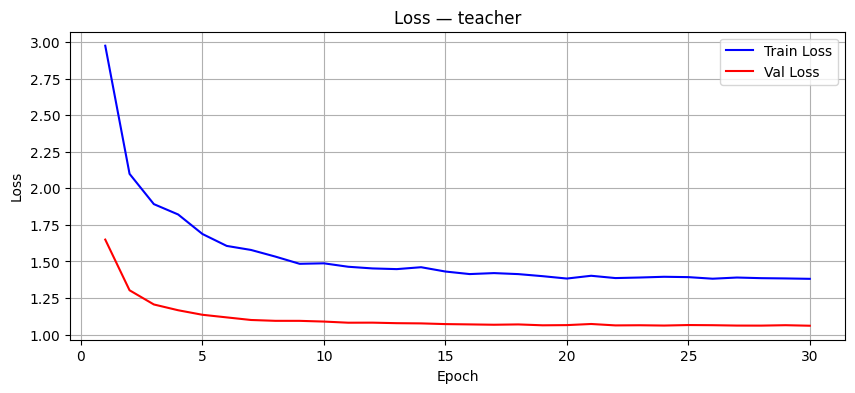

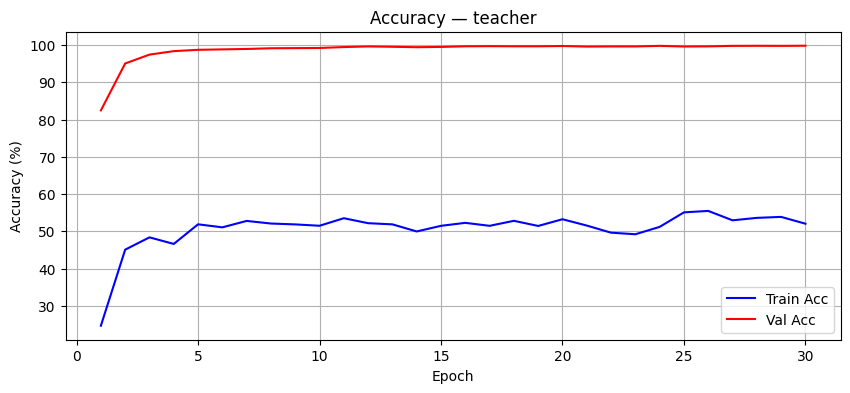

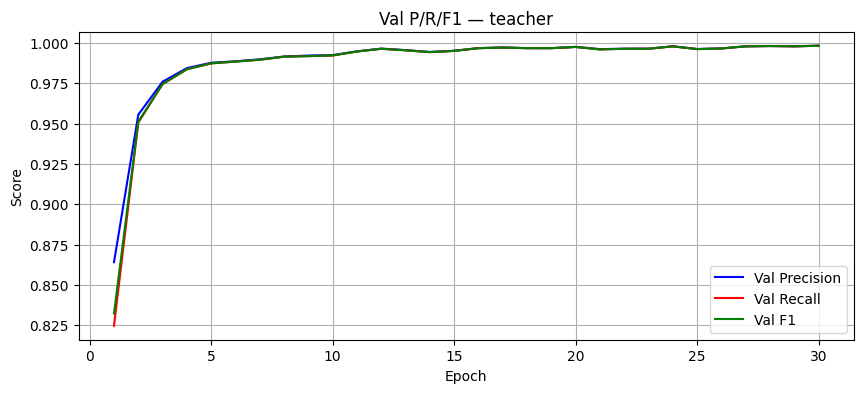

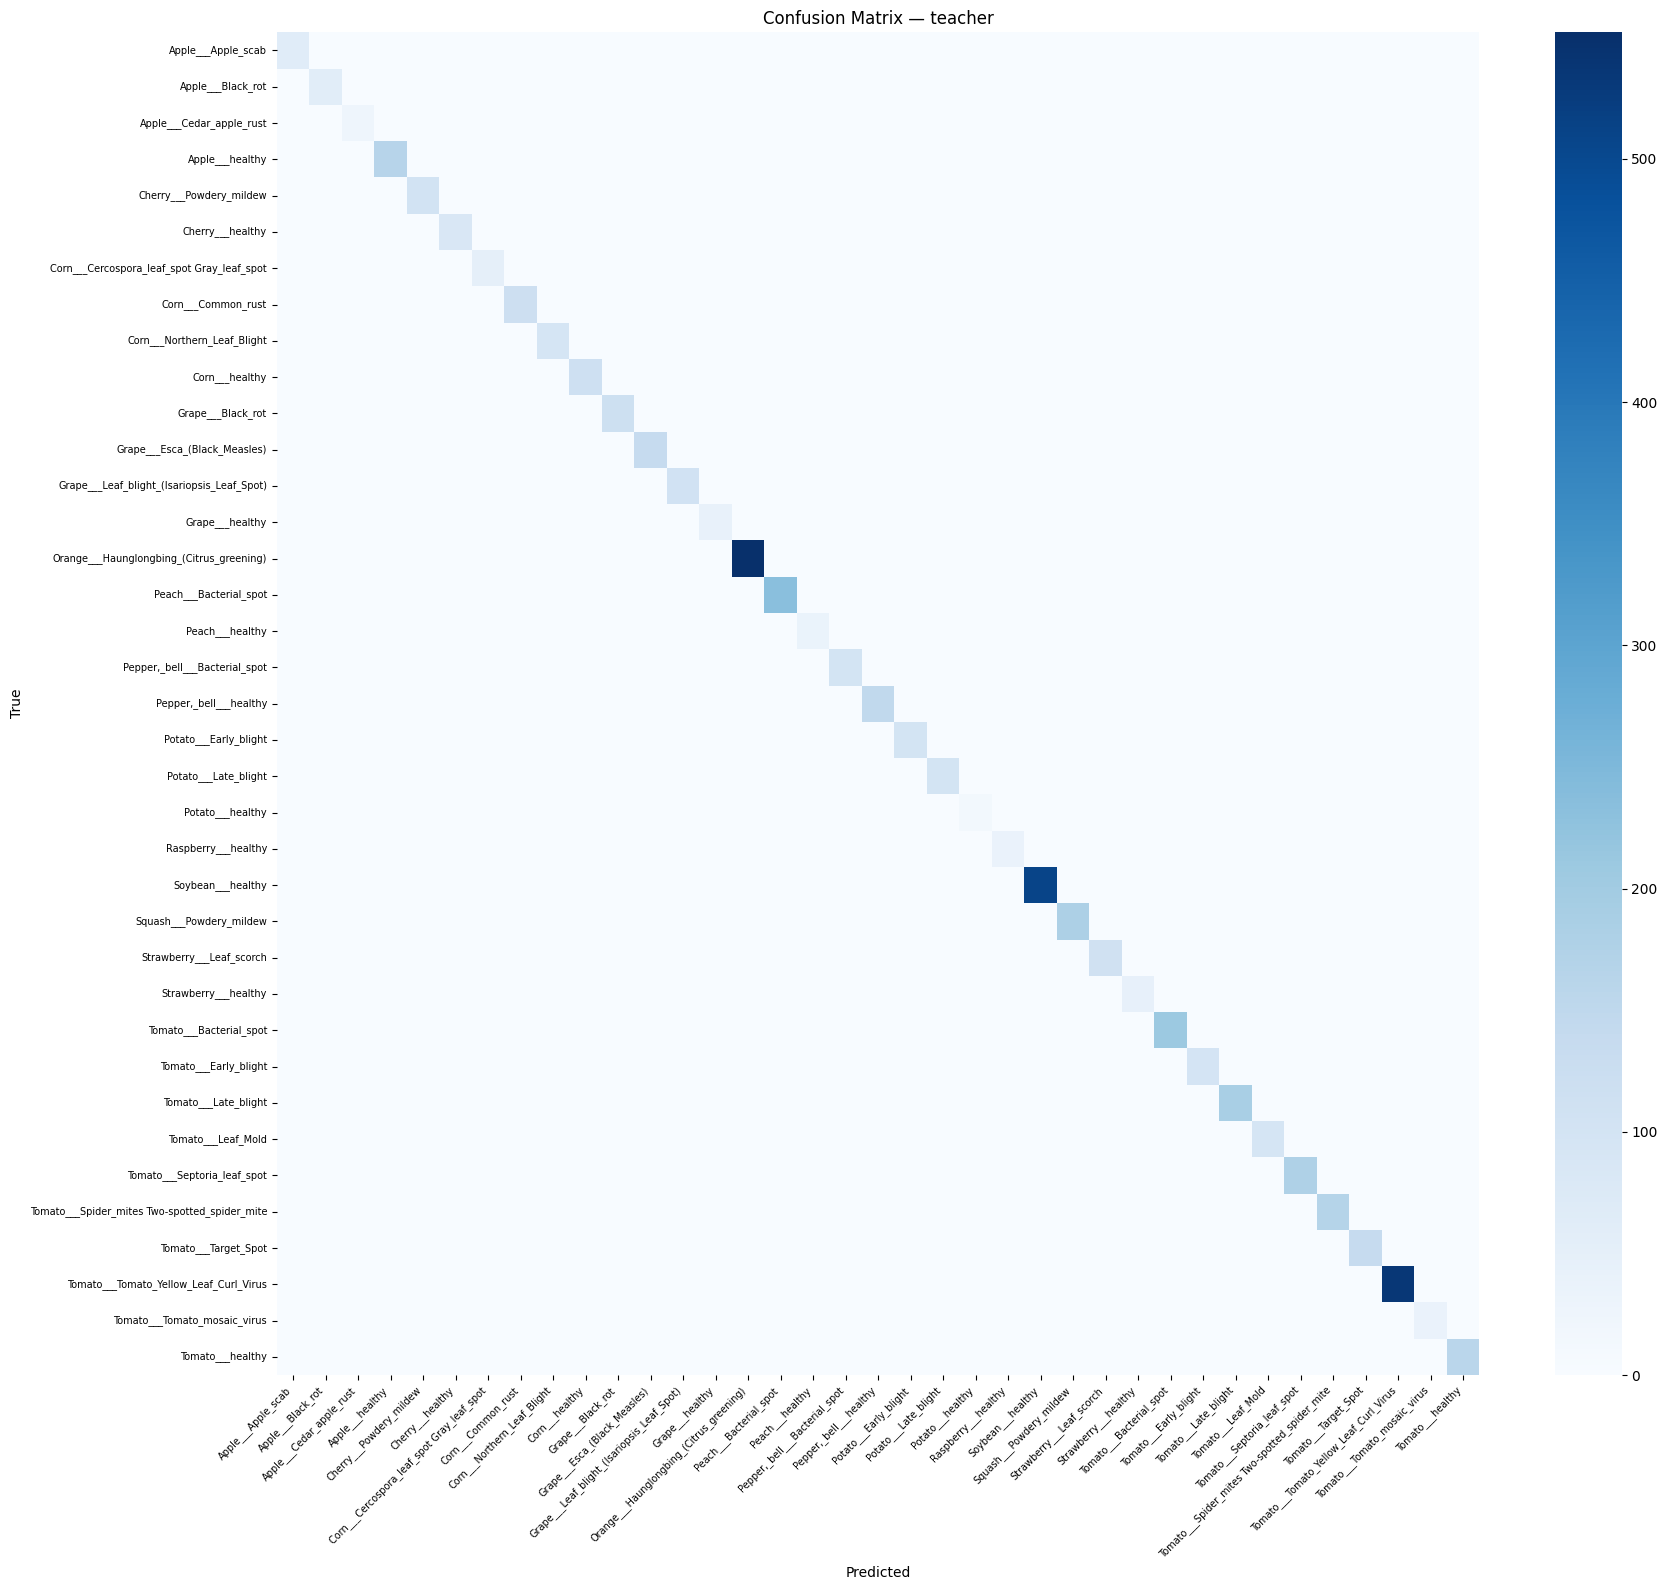


Teacher training complete.
Best checkpoint: /content/drive/MyDrive/Research/Model_save/PlantVillage/best_teacher.pt


In [ ]:
# ════════════════════════════════════════════════════════
# STEP 1 — Train Teacher (ViT-B/16)
# ════════════════════════════════════════════════════════
print("Initialising ViT-B/16 teacher...")
teacher_model = timm.create_model(
    "vit_base_patch16_224", pretrained=True, num_classes=num_classes).to(device)

param_groups = get_layer_wise_params(teacher_model,
                                     base_lr=CFG["teacher_base_lr"],
                                     decay=CFG["lr_decay"])
teacher_optimizer = torch.optim.AdamW(param_groups, weight_decay=CFG["teacher_wd"])

from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
warmup_sched  = LinearLR(teacher_optimizer, start_factor=0.1, end_factor=1.0,
                         total_iters=CFG["teacher_warmup"])
cosine_sched  = CosineAnnealingLR(teacher_optimizer,
                                  T_max=CFG["teacher_epochs"] - CFG["teacher_warmup"],
                                  eta_min=1e-6)
teacher_sched = SequentialLR(teacher_optimizer,
                              schedulers=[warmup_sched, cosine_sched],
                              milestones=[CFG["teacher_warmup"]])

teacher_criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG["label_smoothing"], weight=class_weights)

teacher_ckpt = os.path.join(OUTPUT_DIR, "best_teacher.pt")
teacher_es   = EarlyStopping(patience=CFG["teacher_patience"], delta=0.001,
                              verbose=True, path=teacher_ckpt)

teacher_model = train_teacher(
    teacher_model, train_loader, val_loader,
    teacher_criterion, teacher_optimizer, teacher_sched,
    CFG["teacher_epochs"], device, teacher_es, OUTPUT_DIR
)
print("\nTeacher training complete.")
print(f"Best checkpoint: {teacher_ckpt}")

Initialising EfficientNet-B0 student...


Student Epochs:   2%|▏         | 1/60 [05:45<5:39:36, 345.37s/it]

[Student] Epoch   1 | T-Loss:1.7110 T-Acc:40.40% | V-Loss:1.2811 V-Acc:94.19% V-F1:0.9482
  Val F1 improved (0.0000 → 0.9482). Saving model.


Student Epochs:   3%|▎         | 2/60 [11:29<5:33:16, 344.76s/it]

[Student] Epoch   2 | T-Loss:1.4620 T-Acc:46.94% | V-Loss:1.1970 V-Acc:96.92% V-F1:0.9703
  Val F1 improved (0.9482 → 0.9703). Saving model.


...

[Student] Epoch  28 | T-Loss:1.2168 T-Acc:50.22% | V-Loss:1.1114 V-Acc:99.49% V-F1:0.9949
  EarlyStopping: 10/12


Student Epochs:  48%|████▊     | 29/60 [2:46:32<2:58:03, 344.63s/it]

[Student] Epoch  29 | T-Loss:1.2391 T-Acc:48.89% | V-Loss:1.1223 V-Acc:99.57% V-F1:0.9957
  EarlyStopping: 11/12


Student Epochs:  48%|████▊     | 29/60 [2:52:17<3:04:10, 356.45s/it]

[Student] Epoch  30 | T-Loss:1.2284 T-Acc:48.89% | V-Loss:1.1177 V-Acc:99.55% V-F1:0.9955
  EarlyStopping: 12/12
Early stopping triggered (Student).


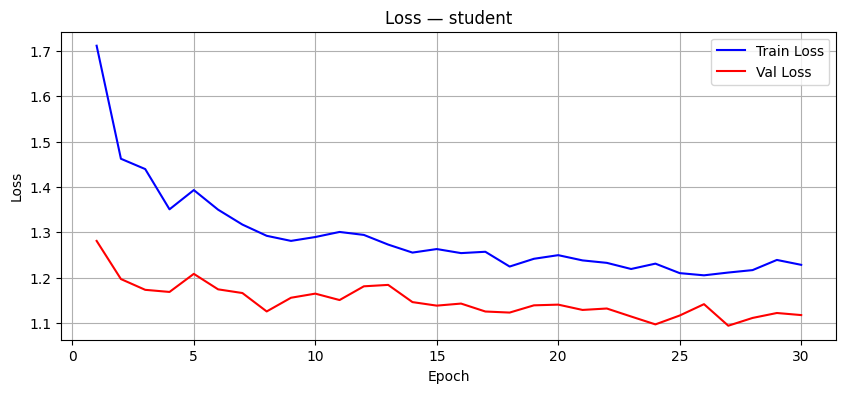

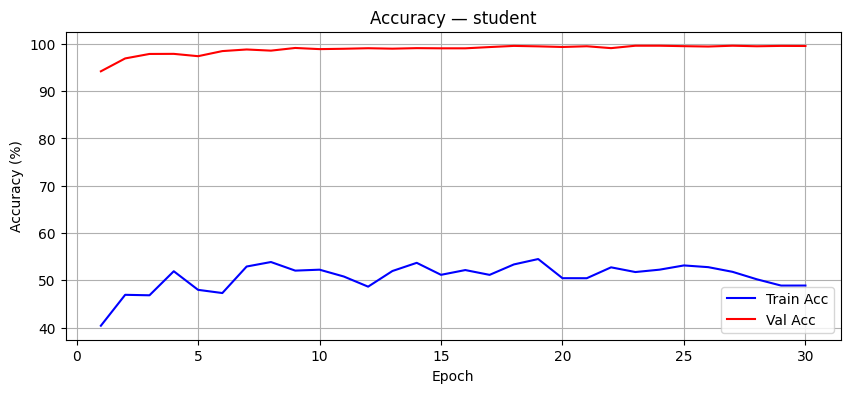

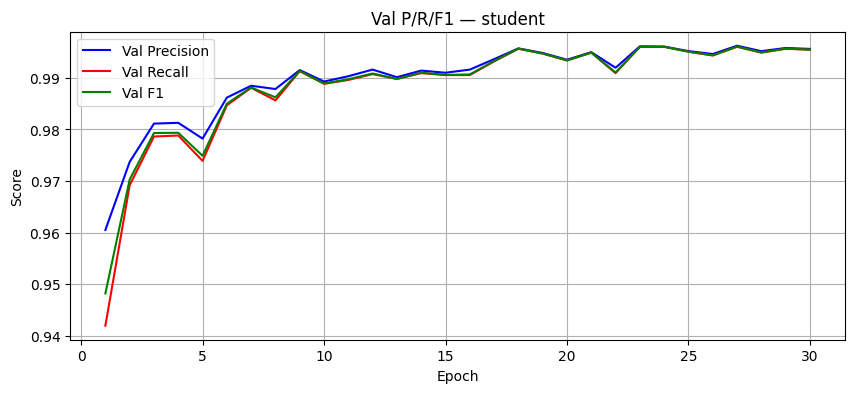

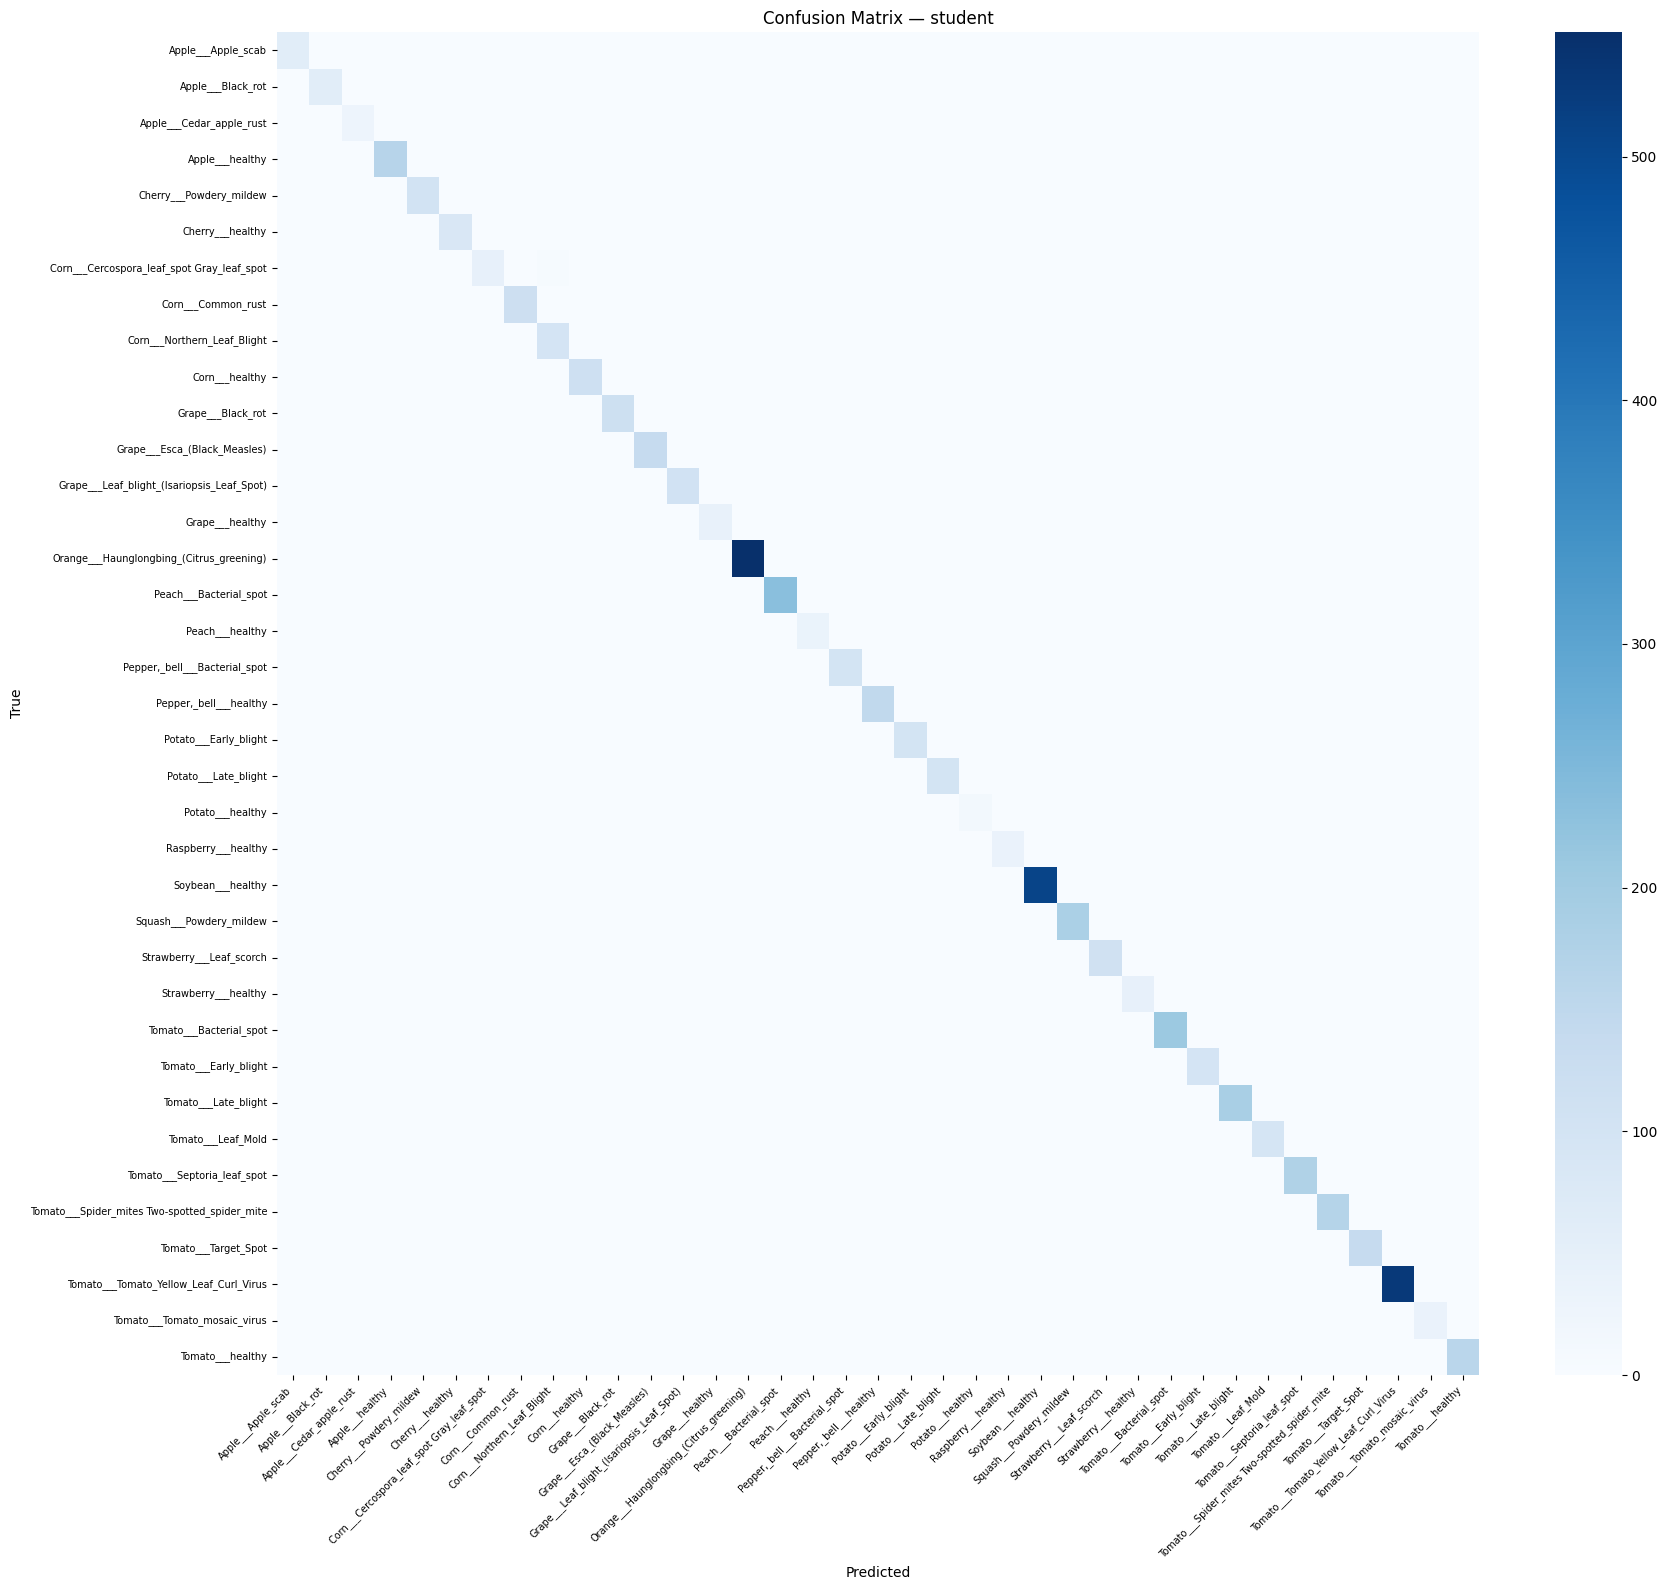

  [Clean FP32] → /content/drive/MyDrive/Research/Model_save/PlantVillage/clean_student_fp32.pt  (15.47 MB)

Student training complete.
Best checkpoint: /content/drive/MyDrive/Research/Model_save/PlantVillage/best_student.pt


In [ ]:
# ════════════════════════════════════════════════════════
# STEP 2 — Train Student (EfficientNet-B0) via KD
# ════════════════════════════════════════════════════════
print("Initialising EfficientNet-B0 student...")

# Reload best teacher (safe if this cell is re-run independently)
teacher_model = timm.create_model(
    "vit_base_patch16_224", pretrained=False, num_classes=num_classes)
teacher_model.load_state_dict(torch.load(teacher_ckpt, weights_only=True))
teacher_model = teacher_model.to(device).eval()

student_model = StudentNet(num_classes=num_classes).to(device)

student_criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG["label_smoothing"], weight=class_weights)
student_optimizer = torch.optim.AdamW(student_model.parameters(),
                                      lr=CFG["student_lr"],
                                      weight_decay=CFG["student_wd"])
student_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
    student_optimizer, T_max=CFG["student_epochs"], eta_min=1e-6)

student_ckpt = os.path.join(OUTPUT_DIR, "best_student.pt")
student_es   = EarlyStopping(patience=CFG["student_patience"], delta=0.001,
                              verbose=True, path=student_ckpt)

student_model, student_metrics = train_student(
    student_model, teacher_model,
    train_loader, val_loader,
    student_criterion, student_optimizer, student_sched,
    CFG["student_epochs"], device, student_es, OUTPUT_DIR
)

save_clean_student(
    student_model,
    save_path_fp32=os.path.join(OUTPUT_DIR, "clean_student_fp32.pt"),
    save_path_fp16=None,
    num_classes=num_classes, device=device
)
print("\nStudent training complete.")
print(f"Best checkpoint: {student_ckpt}")

Starting QAT fine-tuning...


/tmp/ipykernel_3802/3063416250.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_3802/3063416250.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_3802/3063416250.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


[QAT] Epoch   1 | T-Loss:1.0854 T-Acc:49.94% | V-Loss:0.5213 V-Acc:99.62%
[QAT] Epoch   2 | T-Loss:1.0686 T-Acc:51.65% | V-Loss:0.5236 V-Acc:99.68%
[QAT] Epoch   3 | T-Loss:1.0584 T-Acc:51.41% | V-Loss:0.5237 V-Acc:99.68%
[QAT] Epoch   4 | T-Loss:1.0627 T-Acc:53.35% | V-Loss:0.5326 V-Acc:99.62%
[QAT] Epoch   5 | T-Loss:1.0786 T-Acc:51.43% | V-Loss:0.5342 V-Acc:99.70%
[QAT] Epoch   6 | T-Loss:1.0446 T-Acc:51.63% | V-Loss:0.5226 V-Acc:99.64%
[QAT] Epoch   7 | T-Loss:1.0874 T-Acc:49.87% | V-Loss:0.5274 V-Acc:99.70%
[QAT] Epoch   8 | T-Loss:1.0787 T-Acc:50.02% | V-Loss:0.5374 V-Acc:99.66%
[QAT] Epoch   9 | T-Loss:1.0485 T-Acc:53.81% | V-Loss:0.5098 V-Acc:99.66%
[QAT] Epoch  10 | T-Loss:1.0673 T-Acc:52.00% | V-Loss:0.5049 V-Acc:99.66%
[QAT] Epoch  11 | T-Loss:1.0684 T-Acc:51.62% | V-Loss:0.5281 V-Acc:99.68%
[QAT] Epoch  12 | T-Loss:1.0842 T-Acc:49.83% | V-Loss:0.5212 V-Acc:99.72%
[QAT] Epoch  13 | T-Loss:1.0711 T-Acc:51.20% | V-Loss:0.5088 V-Acc:99.72%
[QAT] Epoch  14 | T-Loss:1.0436 T-Acc:

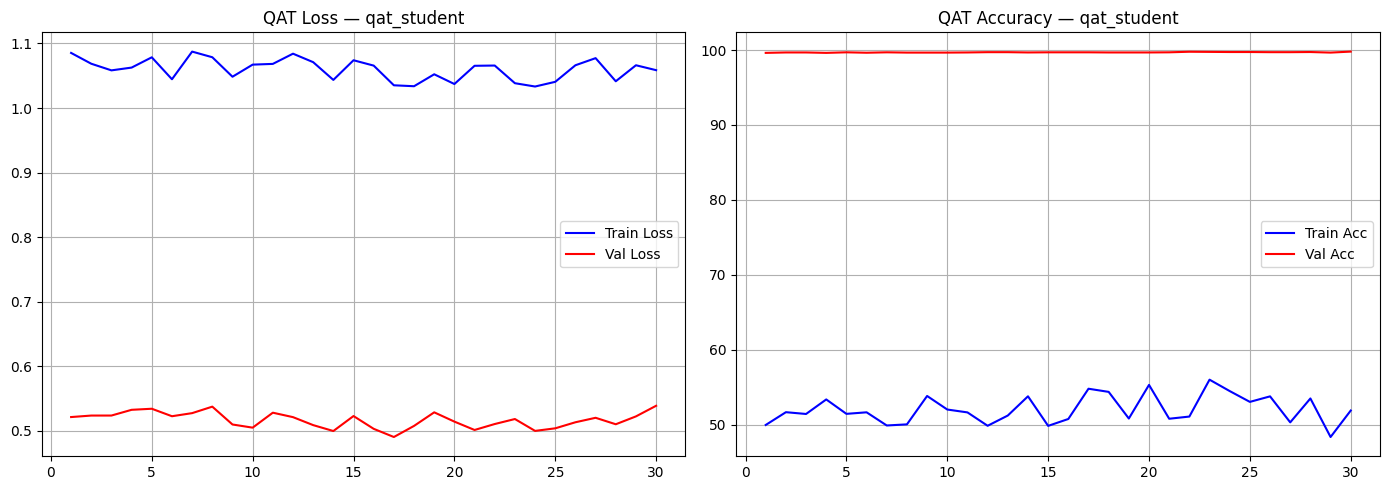


QAT training complete.
Best QAT checkpoint: /content/drive/MyDrive/Research/Model_save/PlantVillage/qat_student_best.pth


In [ ]:
# ════════════════════════════════════════════════════════
# STEP 3 — QAT Fine-tuning (FP16 AMP)
# ════════════════════════════════════════════════════════
print("Starting QAT fine-tuning...")

teacher_model = timm.create_model(
    "vit_base_patch16_224", pretrained=False, num_classes=num_classes)
teacher_model.load_state_dict(torch.load(teacher_ckpt, weights_only=True))
teacher_model = teacher_model.to(device).eval()

qat_model, qat_model_fp16, qat_ckpt, qat_train_metrics = train_qat_student(
    student_ckpt_path=student_ckpt,
    teacher_model=teacher_model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_classes=num_classes,
    output_dir=OUTPUT_DIR,
    num_epochs=CFG["qat_epochs"],
    lr=CFG["qat_lr"],
    weight_decay=CFG["qat_wd"],
    patience=CFG["qat_patience"]
)
print("\nQAT training complete.")
print(f"Best QAT checkpoint: {qat_ckpt}")

EVALUATING ALL MODELS ON HELD-OUT TEST SET

[1/3] Teacher (ViT-B/16)...
  Acc:99.60%  Prec:0.9961  Rec:0.9960  F1:0.9960


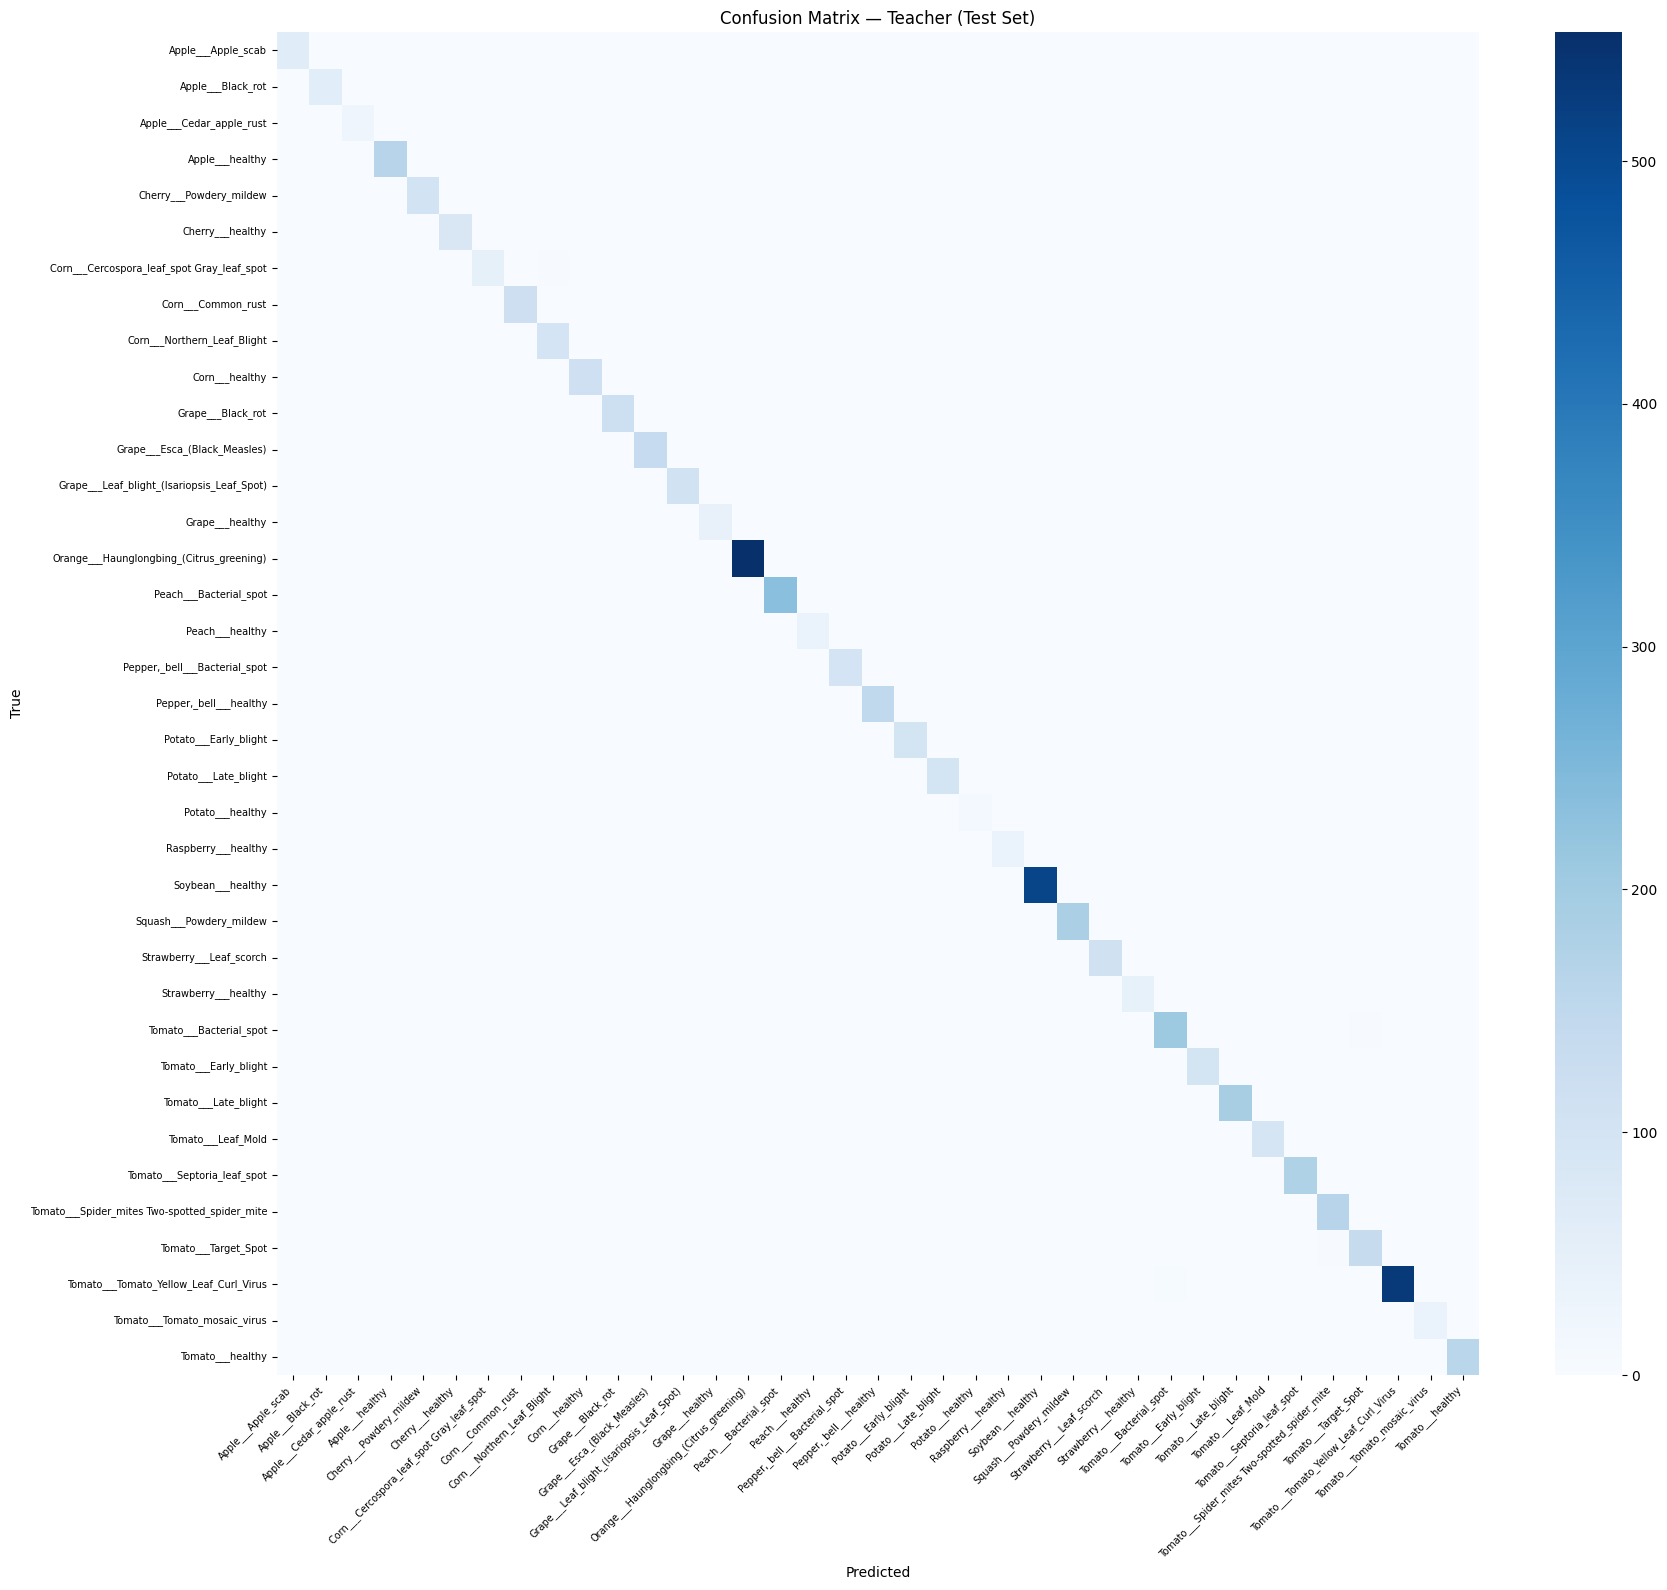


[2/3] Student FP32 (EfficientNet-B0)...
  Acc:99.58%  Prec:0.9960  Rec:0.9958  F1:0.9959


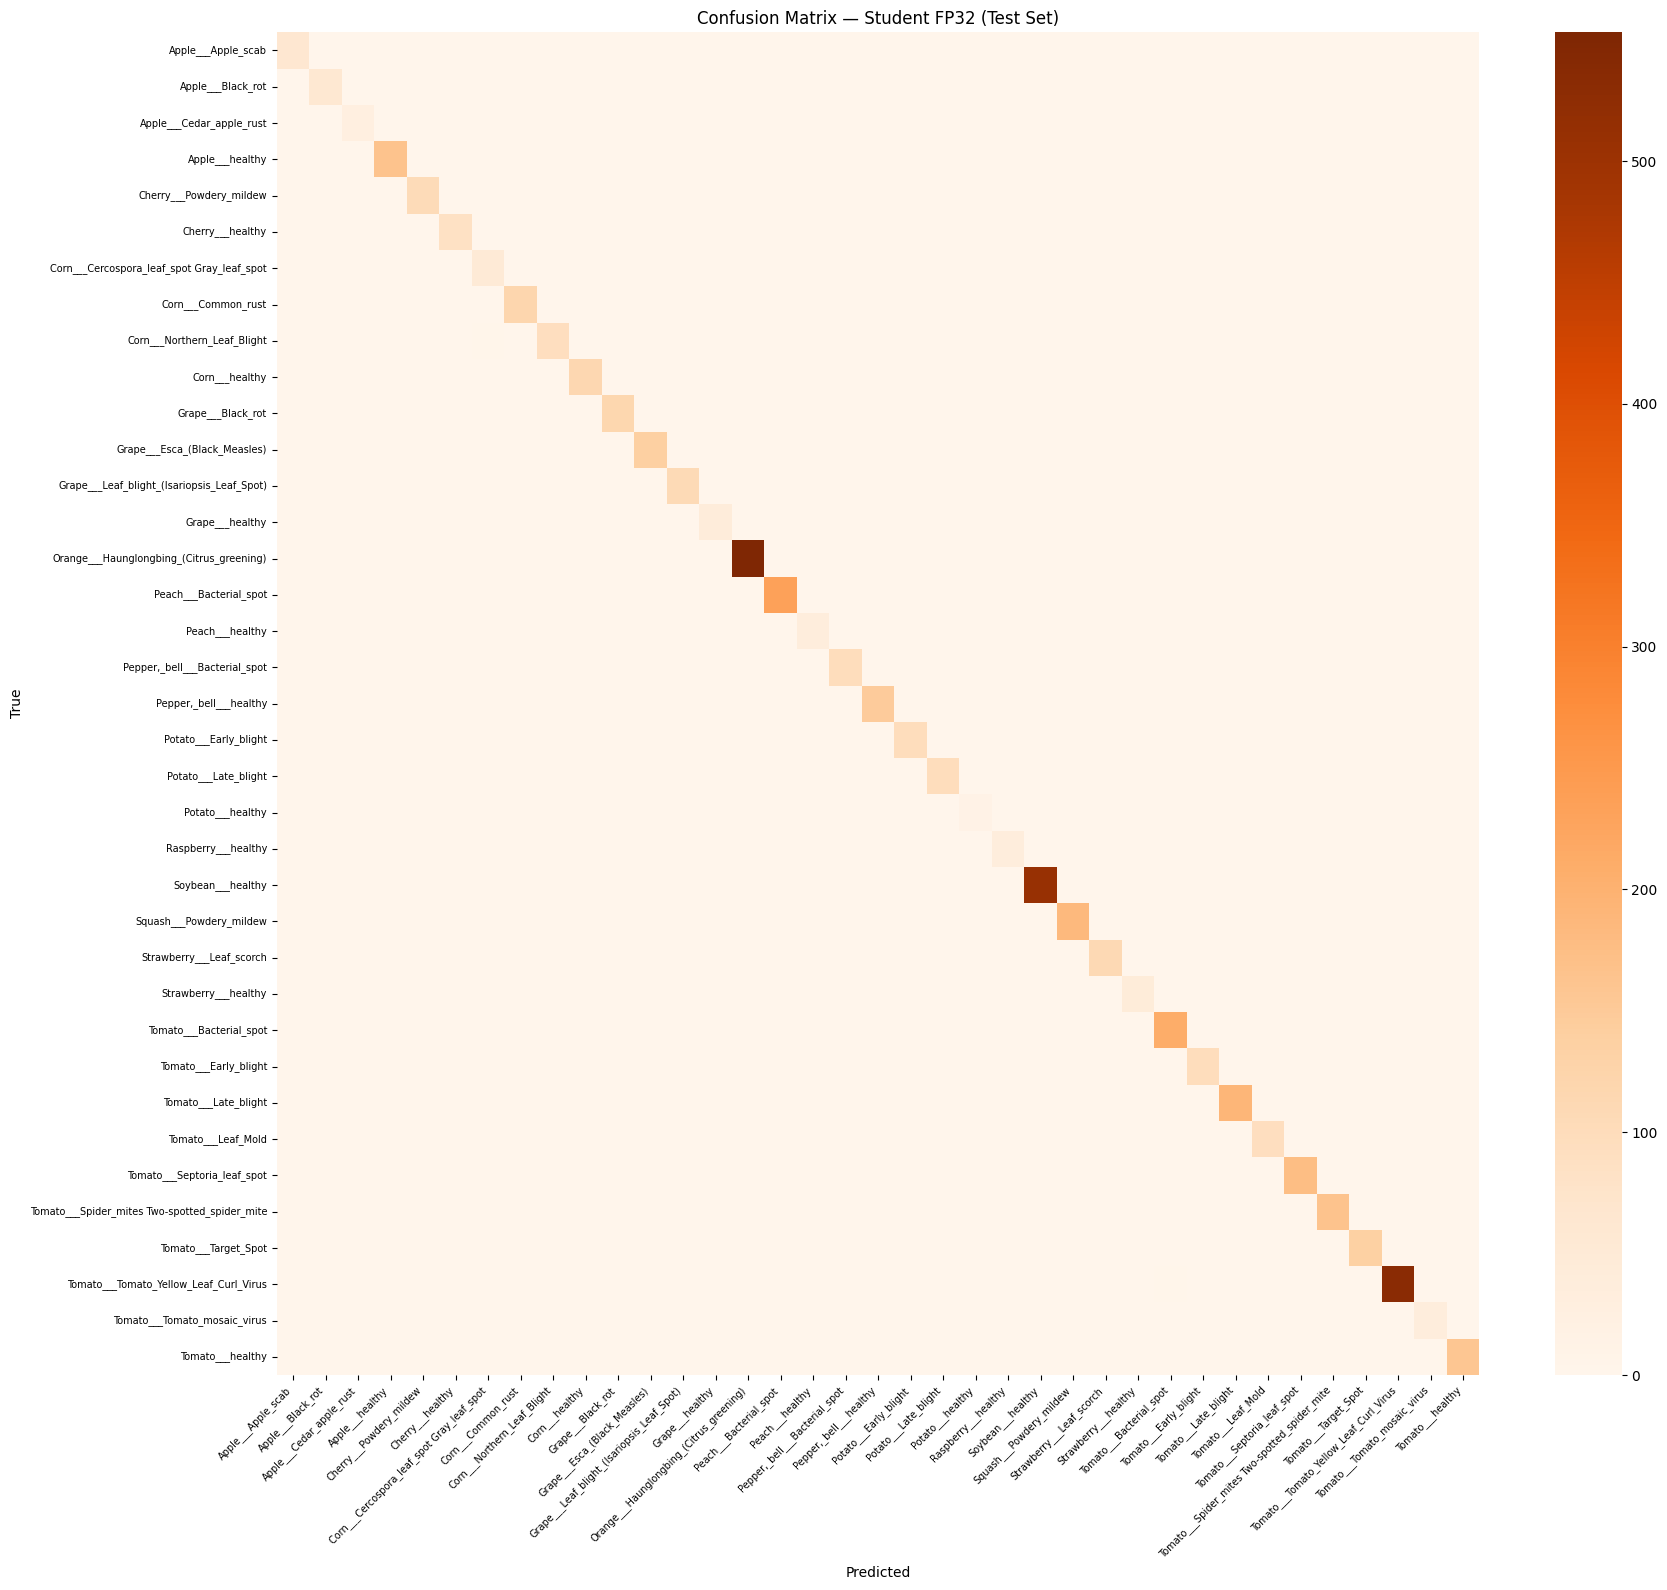


[3/3] QAT Student FP16...
  Acc:99.70%  Prec:0.9970  Rec:0.9970  F1:0.9970


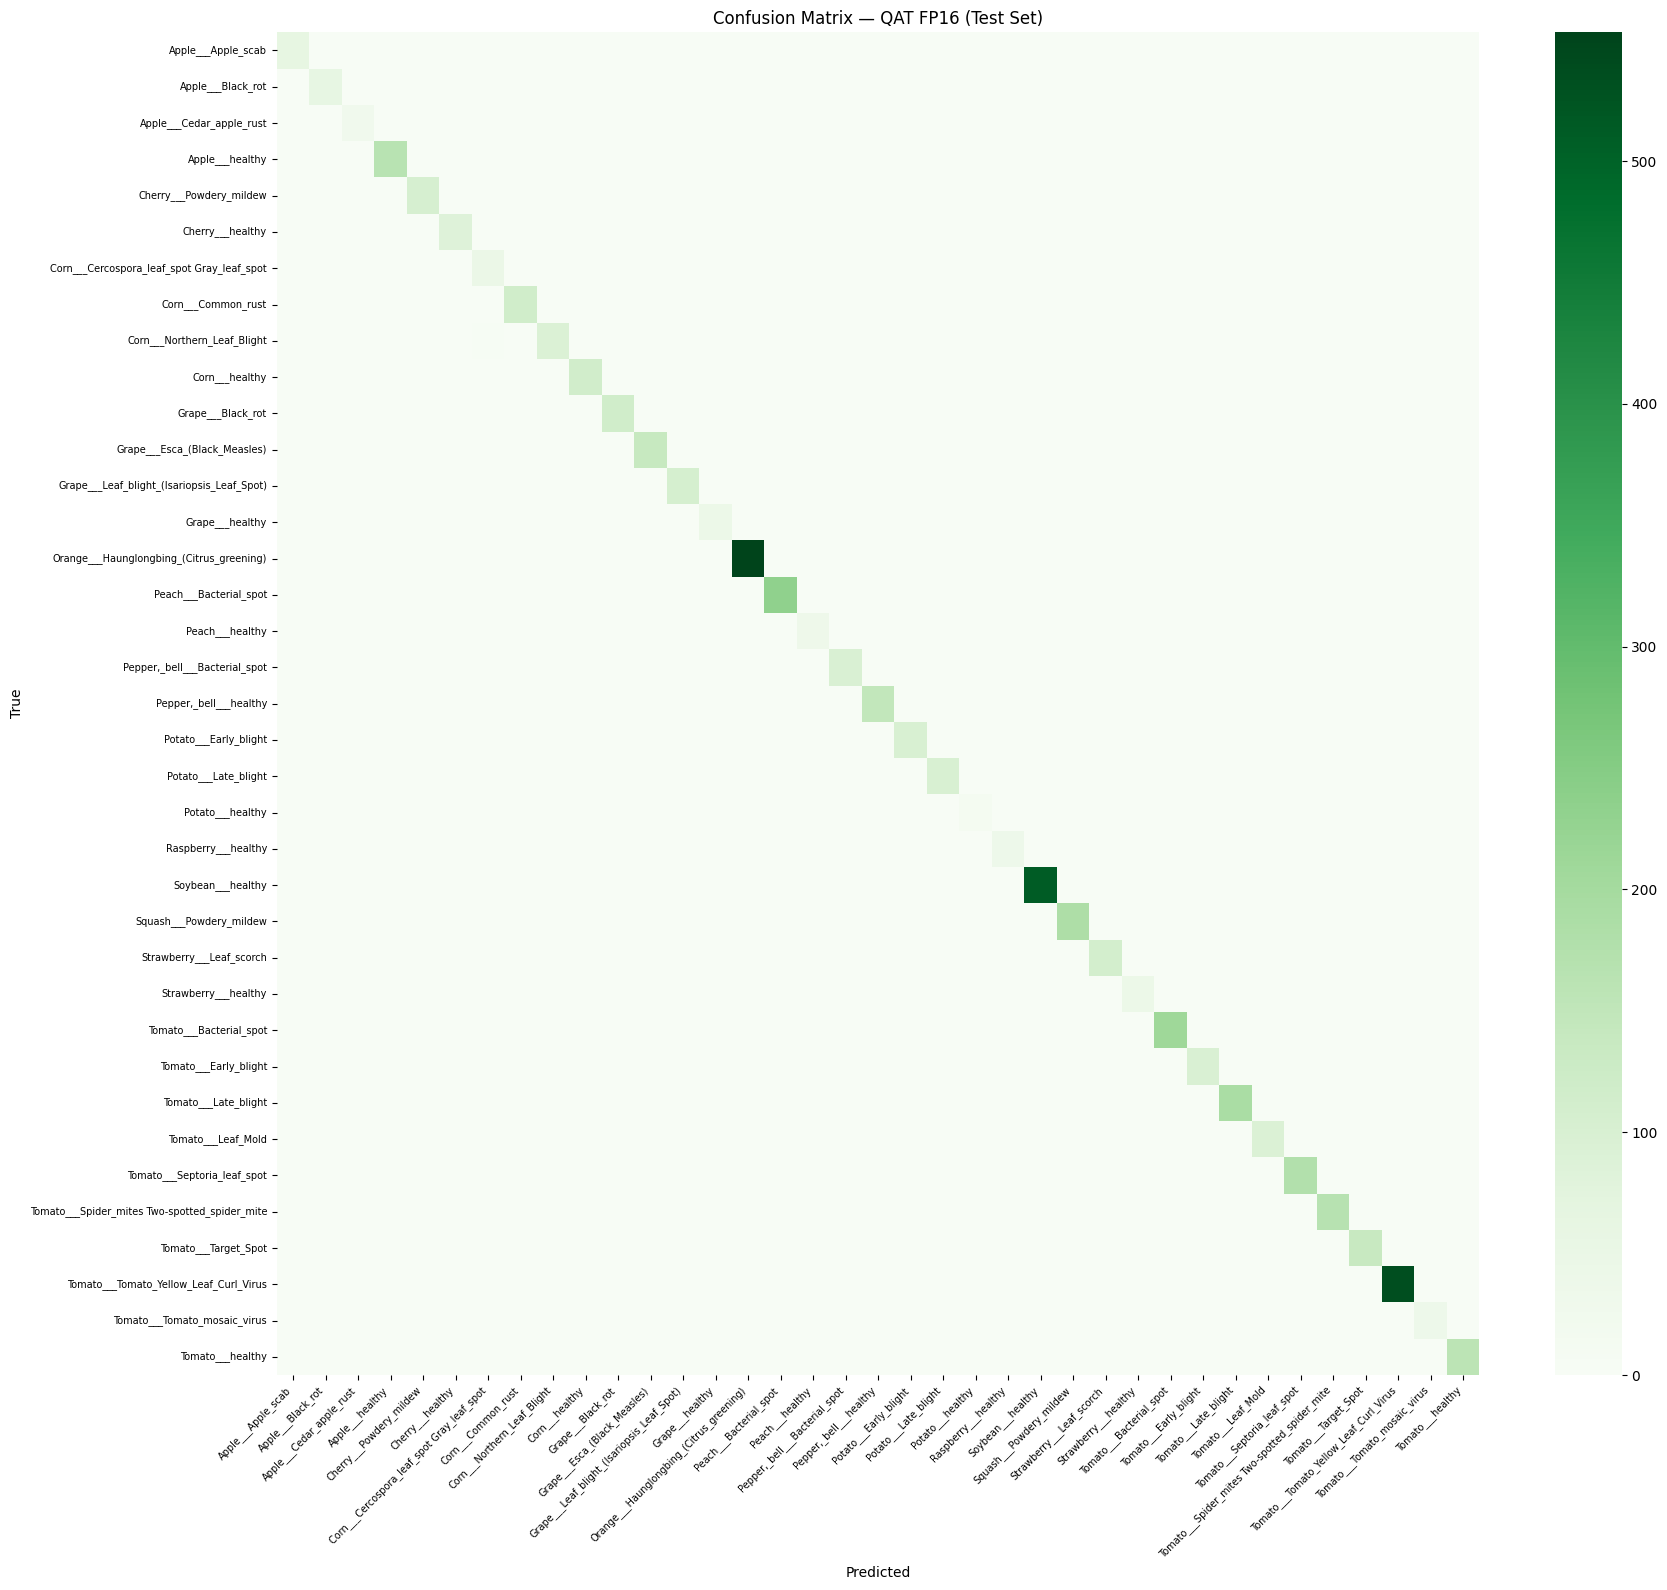


All test evaluations done.


In [ ]:
# ════════════════════════════════════════════════════════
# STEP 4 — Final Evaluation on TEST SET
# ════════════════════════════════════════════════════════
print("=" * 60)
print("EVALUATING ALL MODELS ON HELD-OUT TEST SET")
print("=" * 60)

fig_size = max(12, num_classes // 2)

# ── Teacher ───────────────────────────────────────────────
print("\n[1/3] Teacher (ViT-B/16)...")
teacher_model = timm.create_model(
    "vit_base_patch16_224", pretrained=False, num_classes=num_classes)
teacher_model.load_state_dict(torch.load(teacher_ckpt, weights_only=True))
teacher_model = teacher_model.to(device).eval()

t_acc, t_prec, t_rec, t_f1, t_preds, t_labels = evaluate_on_loader(
    teacher_model, test_loader, device)
print(f"  Acc:{t_acc*100:.2f}%  Prec:{t_prec:.4f}  Rec:{t_rec:.4f}  F1:{t_f1:.4f}")

cm = confusion_matrix(t_labels, t_preds)
plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
plt.title('Confusion Matrix — Teacher (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_teacher_test.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Student FP32 ──────────────────────────────────────────
print("\n[2/3] Student FP32 (EfficientNet-B0)...")
student_model = StudentNet(num_classes=num_classes).to(device)
student_model.load_state_dict(torch.load(student_ckpt, map_location=device, weights_only=True))
student_model.eval()

s_acc, s_prec, s_rec, s_f1, s_preds, s_labels = evaluate_on_loader(
    student_model, test_loader, device)
print(f"  Acc:{s_acc*100:.2f}%  Prec:{s_prec:.4f}  Rec:{s_rec:.4f}  F1:{s_f1:.4f}")

cm = confusion_matrix(s_labels, s_preds)
plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
plt.title('Confusion Matrix — Student FP32 (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_student_test.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── QAT FP16 ──────────────────────────────────────────────
print("\n[3/3] QAT Student FP16...")
qat_model_eval = StudentNet(num_classes=num_classes).to(device)
qat_model_eval.load_state_dict(torch.load(qat_ckpt, map_location=device, weights_only=True))
qat_model_eval.eval()

q_acc, q_prec, q_rec, q_f1, q_preds, q_labels = evaluate_on_loader(
    qat_model_eval, test_loader, device, use_half=True)
print(f"  Acc:{q_acc*100:.2f}%  Prec:{q_prec:.4f}  Rec:{q_rec:.4f}  F1:{q_f1:.4f}")

cm = confusion_matrix(q_labels, q_preds)
plt.figure(figsize=(fig_size, fig_size - 2))
sns.heatmap(cm, annot=(num_classes <= 20), fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 7})
plt.title('Confusion Matrix — QAT FP16 (Test Set)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_qat_test.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

print("\nAll test evaluations done.")

In [ ]:
# ── Per-class Classification Reports ─────────────────────────────────────────
print("\n===== Per-class Report: Teacher =====")
print(classification_report(t_labels, t_preds, target_names=class_names, zero_division=0))

print("\n===== Per-class Report: Student FP32 =====")
print(classification_report(s_labels, s_preds, target_names=class_names, zero_division=0))

print("\n===== Per-class Report: QAT FP16 =====")
print(classification_report(q_labels, q_preds, target_names=class_names, zero_division=0))

def report_to_df(labels, preds, names):
    rpt = classification_report(labels, preds, target_names=names,
                                 zero_division=0, output_dict=True)
    return pd.DataFrame(rpt).transpose()

report_to_df(t_labels, t_preds, class_names).to_csv(
    os.path.join(OUTPUT_DIR, "report_teacher.csv"))
report_to_df(s_labels, s_preds, class_names).to_csv(
    os.path.join(OUTPUT_DIR, "report_student.csv"))
report_to_df(q_labels, q_preds, class_names).to_csv(
    os.path.join(OUTPUT_DIR, "report_qat.csv"))
print("Per-class reports saved.")


===== Per-class Report: Teacher =====
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       1.00      1.00      1.00        63
                            Apple___Black_rot       1.00      1.00      1.00        62
                     Apple___Cedar_apple_rust       1.00      1.00      1.00        27
                              Apple___healthy       1.00      1.00      1.00       165
                      Cherry___Powdery_mildew       1.00      1.00      1.00       105
                             Cherry___healthy       1.00      1.00      1.00        85
   Corn___Cercospora_leaf_spot Gray_leaf_spot       1.00      0.94      0.97        51
                           Corn___Common_rust       1.00      1.00      1.00       119
                  Corn___Northern_Leaf_Blight       0.97      1.00      0.98        98
                               Corn___healthy       1.00      1.00      1.00       116
   

In [ ]:
# ── Model Size & Inference Latency Benchmarks ────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def deployed_params(student_net_model):
    return sum(p.numel() for n, p in student_net_model.named_parameters()
               if p.requires_grad and not n.startswith('feature_adapter'))

def measure_latency(model, loader, n_warmup=10, n_runs=50, use_half=False):
    model.eval().to(device)
    if use_half: model = model.half()
    images, _ = next(iter(loader))
    images = images.to(device)
    if use_half: images = images.half()
    for _ in range(n_warmup):
        _ = model(images)
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(n_runs):
        _ = model(images)
    if device.type == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / n_runs / images.size(0) * 1000

teacher_params  = count_params(teacher_model) / 1e6
stud_params_dep = deployed_params(student_model) / 1e6
stud_fp32_mb    = stud_params_dep * 4
stud_fp16_mb    = stud_params_dep * 2
flops_m         = 413.9

print("Measuring latency (~30 seconds)...")
lat_teacher = measure_latency(teacher_model, test_loader)
lat_student = measure_latency(student_model, test_loader)
lat_qat     = measure_latency(qat_model_eval, test_loader, use_half=True)

print("\n" + "=" * 105)
header = f"{'Model':<22} | {'Acc':>7} | {'Prec':>6} | {'Rec':>6} | {'F1':>6} | {'Params':>8} | {'Size':>8} | {'FLOPs':>8} | {'Latency ms/img':>14}"
print(header)
print("-" * 105)
print(f"{'Teacher (ViT-B/16)':<22} | {t_acc*100:>6.2f}% | {t_prec:>6.4f} | {t_rec:>6.4f} | {t_f1:>6.4f} | {teacher_params:>7.1f}M | {'~330 MB':>8} | {'—':>8} | {lat_teacher:>13.2f}")
print(f"{'FP32 Student (EffB0)':<22} | {s_acc*100:>6.2f}% | {s_prec:>6.4f} | {s_rec:>6.4f} | {s_f1:>6.4f} | {stud_params_dep:>7.2f}M | {stud_fp32_mb:>6.2f} MB | {flops_m:>6.1f}M | {lat_student:>13.2f}")
print(f"{'FP16 QAT (EffB0)':<22} | {q_acc*100:>6.2f}% | {q_prec:>6.4f} | {q_rec:>6.4f} | {q_f1:>6.4f} | {stud_params_dep:>7.2f}M | {stud_fp16_mb:>6.2f} MB | {flops_m:>6.1f}M | {lat_qat:>13.2f}")
print("=" * 105)

results_df = pd.DataFrame([
    {"Model": "Teacher (ViT-B/16)",   "Accuracy": t_acc*100, "Precision": t_prec, "Recall": t_rec, "F1": t_f1,
     "Params_M": teacher_params,      "Size_MB": 330,        "FLOPs_M": None,     "Latency_ms": lat_teacher},
    {"Model": "FP32 Student (EffB0)", "Accuracy": s_acc*100, "Precision": s_prec, "Recall": s_rec, "F1": s_f1,
     "Params_M": stud_params_dep,     "Size_MB": stud_fp32_mb, "FLOPs_M": flops_m, "Latency_ms": lat_student},
    {"Model": "FP16 QAT (EffB0)",     "Accuracy": q_acc*100, "Precision": q_prec, "Recall": q_rec, "F1": q_f1,
     "Params_M": stud_params_dep,     "Size_MB": stud_fp16_mb, "FLOPs_M": flops_m, "Latency_ms": lat_qat},
])
csv_out = os.path.join(OUTPUT_DIR, "final_results_plantvillage.csv")
results_df.to_csv(csv_out, index=False)
print(f"\nResults saved to: {csv_out}")

Measuring latency (~30 seconds)...

Model                  |     Acc |   Prec |    Rec |     F1 |   Params |     Size |    FLOPs | Latency ms/img
---------------------------------------------------------------------------------------------------------
Teacher (ViT-B/16)     |  99.60% | 0.9961 | 0.9960 | 0.9960 |    85.8M |  ~330 MB |        — |          5.03
FP32 Student (EffB0)   |  99.58% | 0.9960 | 0.9958 | 0.9959 |    4.05M |  16.22 MB |  413.9M |          0.90
FP16 QAT (EffB0)       |  99.70% | 0.9970 | 0.9970 | 0.9970 |    4.05M |   8.11 MB |  413.9M |          0.43

Results saved to: /content/drive/MyDrive/Research/Model_save/PlantVillage/final_results_plantvillage.csv


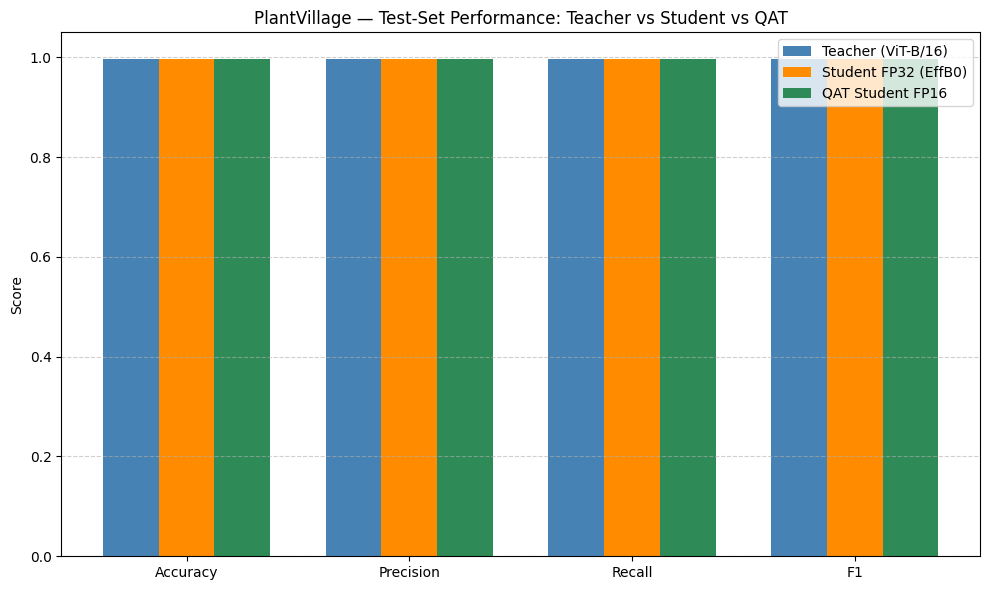

Saved final_comparison.png
All results and plots saved to: /content/drive/MyDrive/Research/Model_save/PlantVillage


In [ ]:
# ── Final Grouped Comparison Plot ────────────────────────────────────────────
teacher_metrics_dict = {"Accuracy": t_acc, "Precision": t_prec, "Recall": t_rec, "F1": t_f1}
student_metrics_dict = {"Accuracy": s_acc, "Precision": s_prec, "Recall": s_rec, "F1": s_f1}
qat_metrics_dict     = {"Accuracy": q_acc, "Precision": q_prec, "Recall": q_rec, "F1": q_f1}

plot_final_comparison(teacher_metrics_dict, student_metrics_dict, qat_metrics_dict, OUTPUT_DIR)
print("All results and plots saved to:", OUTPUT_DIR)

In [ ]:
# ── Speed-up & Compression Summary ───────────────────────────────────────────
speedup_fp32 = lat_teacher / lat_student
speedup_fp16 = lat_teacher / lat_qat

print("\n========== Efficiency Summary ==========")
print(f"  Teacher latency         : {lat_teacher:.2f} ms/img")
print(f"  Student FP32 latency    : {lat_student:.2f} ms/img  →  {speedup_fp32:.1f}× faster than teacher")
print(f"  QAT FP16 latency        : {lat_qat:.2f} ms/img  →  {speedup_fp16:.1f}× faster than teacher")
print(f"  Student FP16 size       : {stud_fp16_mb:.2f} MB   (teacher ≈ 330 MB  →  {330/stud_fp16_mb:.0f}× smaller)")
print(f"  Accuracy drop FP32 KD   : {(t_acc - s_acc)*100:.2f}%  (Teacher → Student)")
print(f"  Accuracy drop QAT FP16  : {(t_acc - q_acc)*100:.2f}%  (Teacher → QAT)")
print(f"  Accuracy change QAT     : {(q_acc - s_acc)*100:+.2f}%  (Student → QAT, + = gain)")
print("=========================================")


========== Efficiency Summary ==========
  Teacher latency         : 5.03 ms/img
  Student FP32 latency    : 0.90 ms/img  →  5.6× faster than teacher
  QAT FP16 latency        : 0.43 ms/img  →  11.8× faster than teacher
  Student FP16 size       : 8.11 MB   (teacher ≈ 330 MB  →  41× smaller)
  Accuracy drop FP32 KD   : 0.02%  (Teacher → Student)
  Accuracy drop QAT FP16  : -0.09%  (Teacher → QAT)
  Accuracy change QAT     : +0.11%  (Student → QAT, + = gain)
